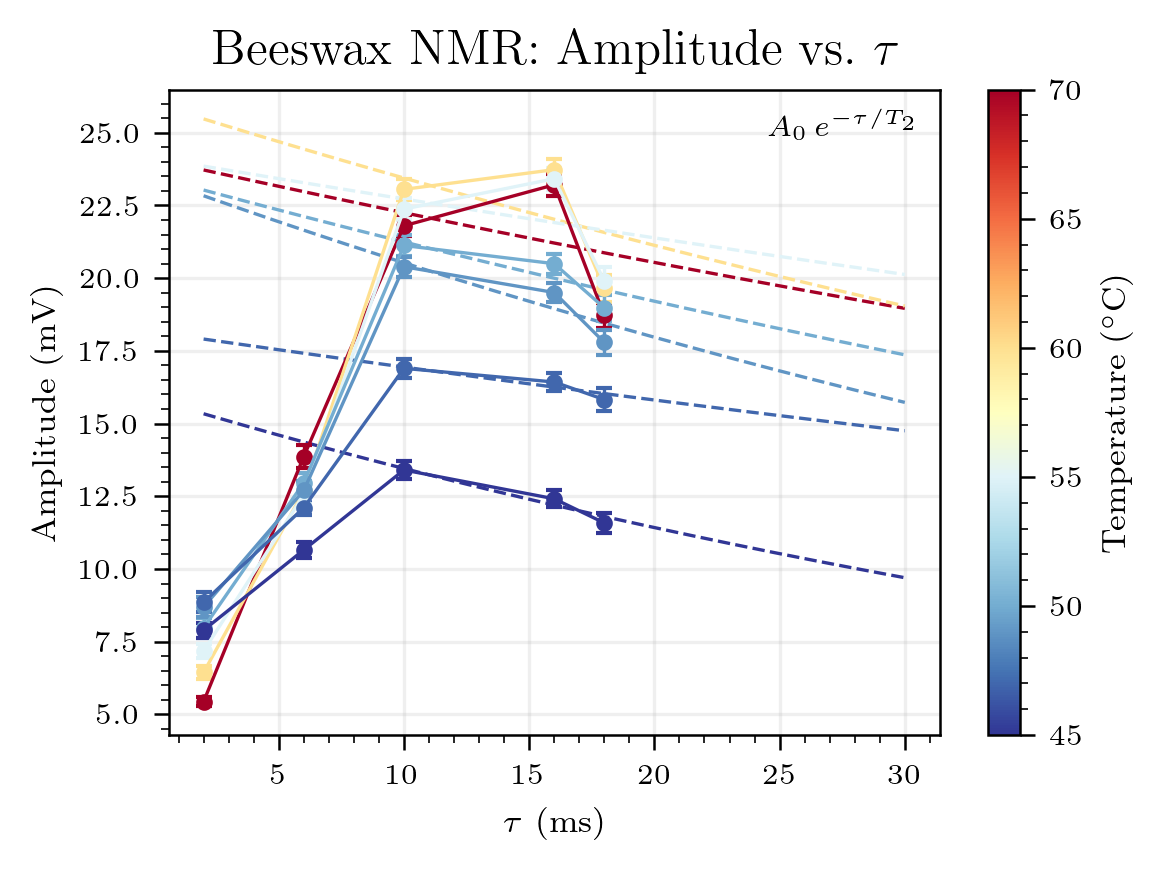

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

plt.style.use('./jlab.mplstyle')

# --- Parse bwax_data.csv ---
# Row layout (after header):
#   row  0    : tau values (ms)
#   row  1    : repeat times TR (ms)
#   rows 2–8  : temperature data (one row per temperature)
#   row  9    : calibration bar height (px)
#   row  10   : calibration bar height (mV)
# Columns alternate: [label, val0, unc0, val1, unc1, ..., val4, unc4]

df = pd.read_csv('bwax_data.csv', header=0)

tau_row      = df.iloc[0]
temp_df      = df.iloc[2:9]
calib_px_row = df.iloc[9]
calib_mV_row = df.iloc[10]

val_slice = slice(1, None, 2)
unc_slice = slice(2, None, 2)

temperatures = temp_df.iloc[:, 0].values.astype(float)
raw_px       = temp_df.iloc[:, val_slice].values.astype(float)
raw_unc      = temp_df.iloc[:, unc_slice].values.astype(float)

taus     = tau_row.iloc[val_slice].values.astype(float)
calib_px = calib_px_row.iloc[val_slice].values.astype(float)
calib_unc= calib_px_row.iloc[unc_slice].values.astype(float)
calib_mV = calib_mV_row.iloc[val_slice].values.astype(float)

# --- Pixel → mV conversion ---
scale      = calib_mV / calib_px
amp_mV     = raw_px * scale[np.newaxis, :]
amp_unc_mV = amp_mV * np.sqrt((raw_unc / raw_px)**2 + (calib_unc / calib_px)**2)

# --- Exponential decay fit (T2) on tau = 10, 16, 18 ms ---
# Model: A(τ) = A0 * exp(−τ / T2)
fit_mask = np.isin(taus, [10, 16, 18])
taus_fit = taus[fit_mask]

def exp_decay(tau, A0, T2):
    return A0 * np.exp(-tau / T2)

T2_vals = np.zeros(len(temperatures))
T2_errs = np.zeros(len(temperatures))
A0_vals = np.zeros(len(temperatures))

for i in range(len(temperatures)):
    y    = amp_mV[i, fit_mask]
    yerr = amp_unc_mV[i, fit_mask]
    p0   = [y[0] * np.exp(taus_fit[0] / 15), 15.0]
    popt, pcov = curve_fit(exp_decay, taus_fit, y, p0=p0, sigma=yerr, absolute_sigma=True)
    A0_vals[i] = popt[0]
    T2_vals[i] = popt[1]
    T2_errs[i] = np.sqrt(pcov[1, 1])

# --- Plot 1: Amplitude vs tau with exponential fits ---
norm     = mcolors.Normalize(vmin=temperatures.min(), vmax=temperatures.max())
cmap     = cm.RdYlBu_r
tau_fine = np.linspace(2, 30, 300)

fig, ax = plt.subplots(figsize=(4, 3))

for i, T in enumerate(temperatures):
    color = cmap(norm(T))
    ax.errorbar(taus, amp_mV[i], yerr=amp_unc_mV[i],
                fmt='o-', color=color, capsize=2, lw=0.8, markersize=3, zorder=3)
    ax.plot(tau_fine, exp_decay(tau_fine, A0_vals[i], T2_vals[i]),
            color=color, lw=0.8, ls='--', zorder=2)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r'Temperature ($^\circ$C)')

ax.text(0.97, 0.97, r'$A_0\,e^{-\tau/T_2}$', transform=ax.transAxes,
        ha='right', va='top', fontsize=7)

ax.set_xlabel(r'$\tau$ (ms)')
ax.set_ylabel(r'Amplitude (mV)')
ax.set_title(r'Beeswax NMR: Amplitude vs.\ $\tau$')
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


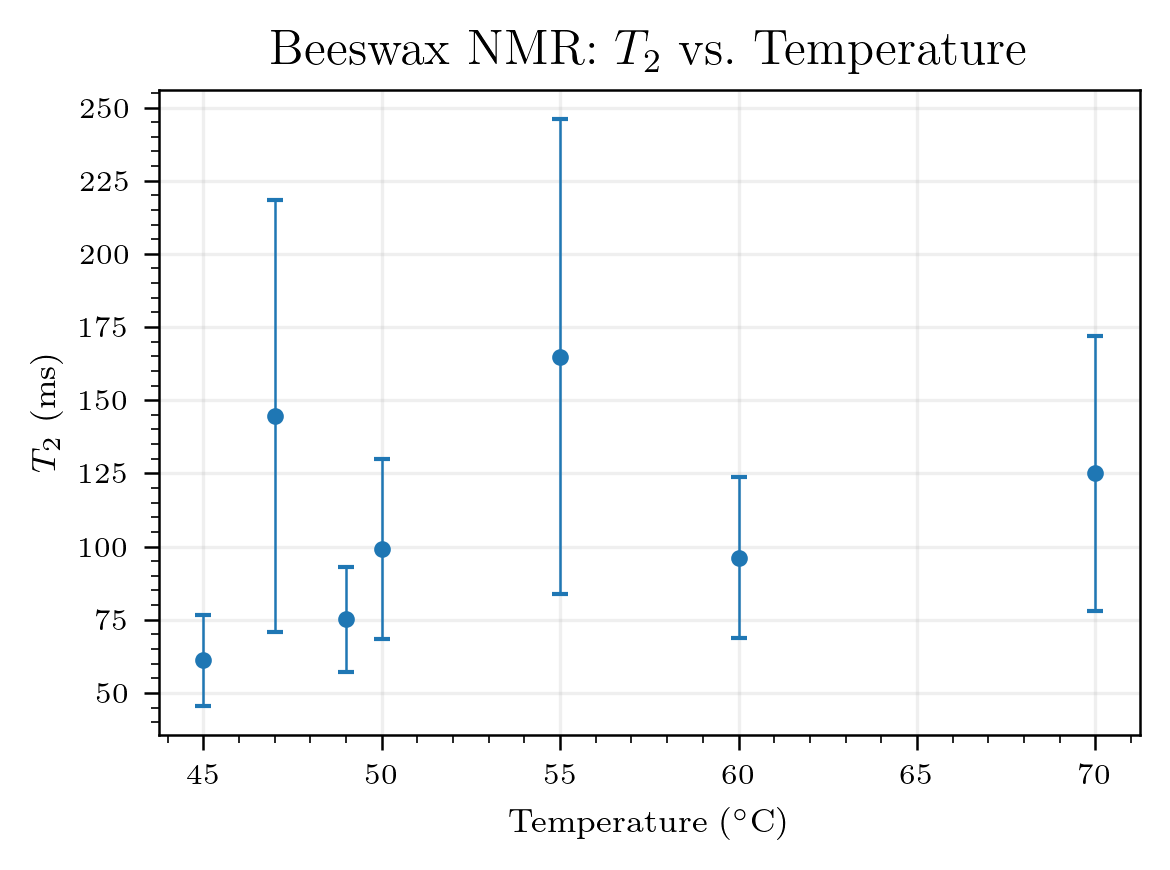

In [40]:
# --- Plot 2: T2 vs Temperature ---
fig, ax = plt.subplots(figsize=(4, 3))

ax.errorbar(temperatures, T2_vals, yerr=T2_errs,
            fmt='o', capsize=2, markersize=3, color='tab:blue')

ax.set_xlabel(r'Temperature ($^\circ$C)')
ax.set_ylabel(r'$T_2$ (ms)')
ax.set_title(r'Beeswax NMR: $T_2$ vs.\ Temperature')
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()
